# Spectral Analysis with Gaussian Fitting

This notebook performs spectral analysis on time-resolved spectroscopy data using multiple Gaussian models and a linear baseline.

## Overview
- Load processed spectral data from CSV
- Filter wavelengths (>=280 nm)
- Fit multiple Gaussian peaks + linear baseline to each time point
- Generate fit reports and visualizations

## Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lmfit.models import GaussianModel, LinearModel

# Enable inline plotting
%matplotlib inline

## Load Data

Update the file path below to point to your processed spectral data:

In [2]:
# Update this path to your data file
# Example: data_file = 'path/to/your/final_pyspec.csv'
data_file = 'final_pyspec.csv'  # Default: look in current directory

# Load the processed data from spec_main.py
data = pd.read_csv(data_file, index_col=0)
print(f"Data shape: {data.shape}")
print("\nFirst few rows:")
display(data.head())

Data shape: (1600, 1000)

First few rows:


,0.0s,0.1s,0.2s,0.3s,0.4s,0.5s,0.6s,0.7s,0.8s,0.9s,...,99.0s,99.1s,99.2s,99.3s,99.4s,99.5s,99.6s,99.7s,99.8s,99.9s
Wavelength,,,,,,,,,,,,,,,,,,,,,
179.18542,0.053905,0.059739,0.046527,0.018479,0.043048,0.006744,0.026478,0.051112,0.070195,0.058708,...,0.042020,0.065579,0.066747,0.071985,0.110226,0.071304,0.050105,0.056017,0.032598,0.078075
179.53008,0.094363,0.176362,0.166037,0.152455,0.136216,0.144560,0.144737,0.120687,0.120436,0.154437,...,0.138167,0.133982,0.133566,0.146415,0.174442,0.207355,0.140838,0.137511,0.199630,0.182874
179.87473,0.030031,0.070411,0.048476,0.056951,0.078438,0.056770,0.040954,0.053428,0.084553,0.051014,...,0.092576,0.095273,0.106191,0.040930,0.078284,0.095187,0.072477,0.112415,0.090116,0.086755
180.21939,0.096595,0.090385,0.093735,0.106415,0.081125,0.125660,0.125004,0.091658,0.110466,0.045038,...,0.087602,0.093939,0.084019,0.123133,0.135508,0.088149,0.125614,0.112053,0.116484,0.103969
180.56404,0.049585,0.074685,0.057200,0.042614,0.037888,0.039702,0.068976,0.044155,0.047949,0.042132,...,0.086299,0.097529,0.056718,0.059630,0.070174,0.076760,0.085632,0.048205,0.080409,0.080853


## Filter Wavelengths

Filter out wavelengths below 280 nm:

In [3]:
# Filter out wavelengths below 280
data = data[data.index.astype(float) >= 280]
print(f"Filtered data shape: {data.shape}")
print(f"Wavelength range: {data.index.astype(float).min():.1f} - {data.index.astype(float).max():.1f} nm")

Filtered data shape: (1307, 1000)
Wavelength range: 280.1 - 727.1 nm


## Define Fitting Model

The model consists of:
- 3 Gaussian peaks (centered around 290, 330, and 412 nm)
- 1 Linear baseline

In [4]:
def create_model():
    """Create the composite model with 3 Gaussians + linear baseline"""
    
    # First Gaussian model (330 nm peak)
    model1 = GaussianModel(prefix='peak1_')
    params1 = model1.make_params(
        amplitude=dict(value=0.2, min=0),
        center=dict(value=330),
        sigma=dict(value=1)
    )
    
    # Second Gaussian model (412 nm peak)
    model2 = GaussianModel(prefix='peak2_')
    params2 = model2.make_params(
        amplitude=dict(value=0.2, min=0),
        center=dict(value=412, min=410, max=420),
        sigma=dict(value=1)
    )
    
    # Linear model for baseline
    model3 = LinearModel(prefix='base_')
    params3 = model3.make_params(
        slope=dict(value=0),
        intercept=dict(value=0)
    )
    
    # Third Gaussian model (290 nm peak)
    model4 = GaussianModel(prefix='peak3_')
    params4 = model4.make_params(
        amplitude=dict(value=0.2, min=0),
        center=dict(value=290, min=280, max=300),
        sigma=dict(value=1, min=0.1, max=1.5)
    )
    
    # Combine the models and parameters
    model = model1 + model2 + model3 + model4
    params = params1 + params2 + params3 + params4
    
    return model, params

## Fit All Time Points

Loop through each time point and fit the model. After the first fit, constrain subsequent fits based on initial results.

In [6]:
# Initialize variables to store the fitted parameters
initial_params = None
fit_results = []

# Loop through each time point and perform the fitting
for i, time_point in enumerate(data.columns):
    y = data[time_point].values  # Absorbance values at the current time point
    x = data.index.values.astype(float)  # Wavelength values
    
    # Create model and parameters
    model, params = create_model()
    
    if initial_params is not None:
        # Update parameters with tight constraints except for amplitude
        for name, param in initial_params.items():
            if 'amplitude' not in name:
                # Only apply tight constraints if value is significantly non-zero
                if abs(param.value) > 1e-10:
                    params[name].set(value=param.value, min=param.value * 0.95, max=param.value * 1.05)
                else:
                    params[name].set(value=param.value)
            else:
                params[name].set(value=param.value, min=0)
    
    # Fit the model to the data
    out = model.fit(y, params, x=x, method='leastsq', max_nfev=10000)
    fit_results.append(out)
    
    if initial_params is None:
        # Store the initial fitted parameters
        initial_params = out.params
    
    # Print progress
    if (i + 1) % 10 == 0:
        print(f"Fitted {i + 1}/{len(data.columns)} time points")

print(f"\nCompleted fitting {len(fit_results)} time points")

Fitted 10/1000 time points
Fitted 20/1000 time points
Fitted 30/1000 time points
Fitted 40/1000 time points
Fitted 50/1000 time points
Fitted 60/1000 time points
Fitted 70/1000 time points
Fitted 80/1000 time points
Fitted 90/1000 time points
Fitted 100/1000 time points
Fitted 110/1000 time points
Fitted 120/1000 time points
Fitted 130/1000 time points
Fitted 140/1000 time points
Fitted 150/1000 time points
Fitted 160/1000 time points
Fitted 170/1000 time points
Fitted 180/1000 time points
Fitted 190/1000 time points
Fitted 200/1000 time points
Fitted 210/1000 time points
Fitted 220/1000 time points
Fitted 230/1000 time points
Fitted 240/1000 time points
Fitted 250/1000 time points
Fitted 260/1000 time points
Fitted 270/1000 time points
Fitted 280/1000 time points
Fitted 290/1000 time points
Fitted 300/1000 time points
Fitted 310/1000 time points
Fitted 320/1000 time points
Fitted 330/1000 time points
Fitted 340/1000 time points
Fitted 350/1000 time points
Fitted 360/1000 time points
F

## Visualize Fits

Plot the first spectrum with fitted components:

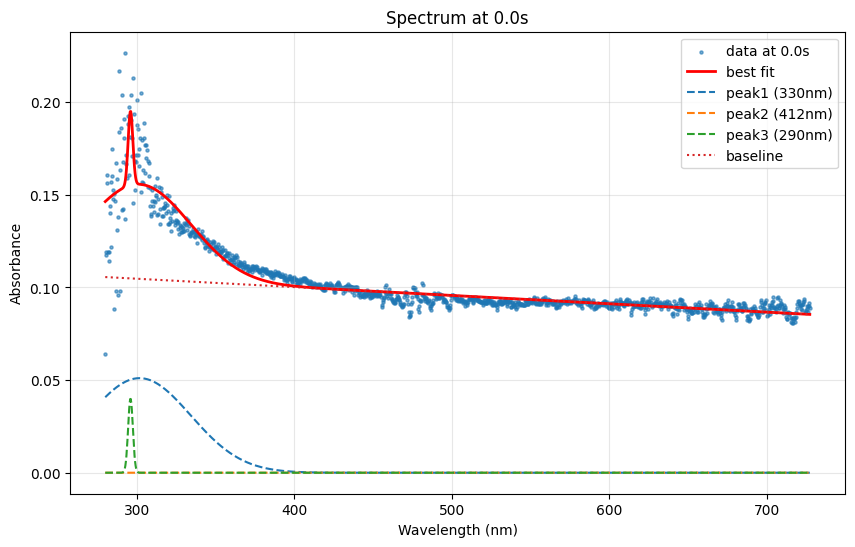

In [7]:
# Plot the first spectrum for checking
if len(fit_results) > 0:
    i = 0
    time_point = data.columns[i]
    out = fit_results[i]
    x = data.index.values.astype(float)
    y = data[time_point].values
    comps = out.eval_components()
    
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, label=f'data at {time_point}', s=5, alpha=0.6)
    plt.plot(x, out.best_fit, label='best fit', color='red', linewidth=2)
    plt.plot(x, comps['peak1_'], label='peak1 (330nm)', linestyle='--')
    plt.plot(x, comps['peak2_'], label='peak2 (412nm)', linestyle='--')
    plt.plot(x, comps['peak3_'], label='peak3 (290nm)', linestyle='--')
    plt.plot(x, comps['base_'], label='baseline', linestyle=':')
    plt.legend()
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Absorbance')
    plt.title(f'Spectrum at {time_point}')
    plt.grid(True, alpha=0.3)
    plt.show()

## View Fit Report

Display the fit report for the first time point:

In [8]:
if len(fit_results) > 0:
    print(f"Fit report for time point: {data.columns[0]}")
    print(fit_results[0].fit_report(min_correl=0.3))

Fit report for time point: 0.0s
[[Model]]
    (((Model(gaussian, prefix='peak1_') + Model(gaussian, prefix='peak2_')) + Model(linear, prefix='base_')) + Model(gaussian, prefix='peak3_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5998
    # data points      = 1307
    # variables        = 11
    chi-square         = 0.07580232
    reduced chi-square = 5.8489e-05
    Akaike info crit   = -12727.9367
    Bayesian info crit = -12671.0063
    R-squared          = 0.87994247
##  Warning: uncertainties could not be estimated:
    peak2_amplitude:  at boundary
    peak3_sigma:      at boundary
[[Variables]]
    peak1_amplitude:  4.15144242 (init = 0.2)
    peak1_center:     301.886699 (init = 330)
    peak1_sigma:      32.4453627 (init = 1)
    peak1_fwhm:       76.4029890 == '2.3548200*peak1_sigma'
    peak1_height:     0.05104538 == '0.3989423*peak1_amplitude/max(1e-15, peak1_sigma)'
    peak2_amplitude:  3.9746e-13 (init = 0.2)
    peak2_center:     412.01

## Save Fit Reports

Save all fit reports to a log file:

In [ ]:
# Write all fit reports to a log file
with open('fit_report.log', 'w') as f:
    for i, (time_point, out) in enumerate(zip(data.columns, fit_results)):
        f.write(f'\nSpectra time_point: {time_point}\n')
        f.write(out.fit_report(min_correl=0.3))
        f.write('\n' + '='*80 + '\n')

print(f"Fit reports saved to 'fit_report.log'")

## Plot Multiple Time Points

Visualize fits at different time intervals:

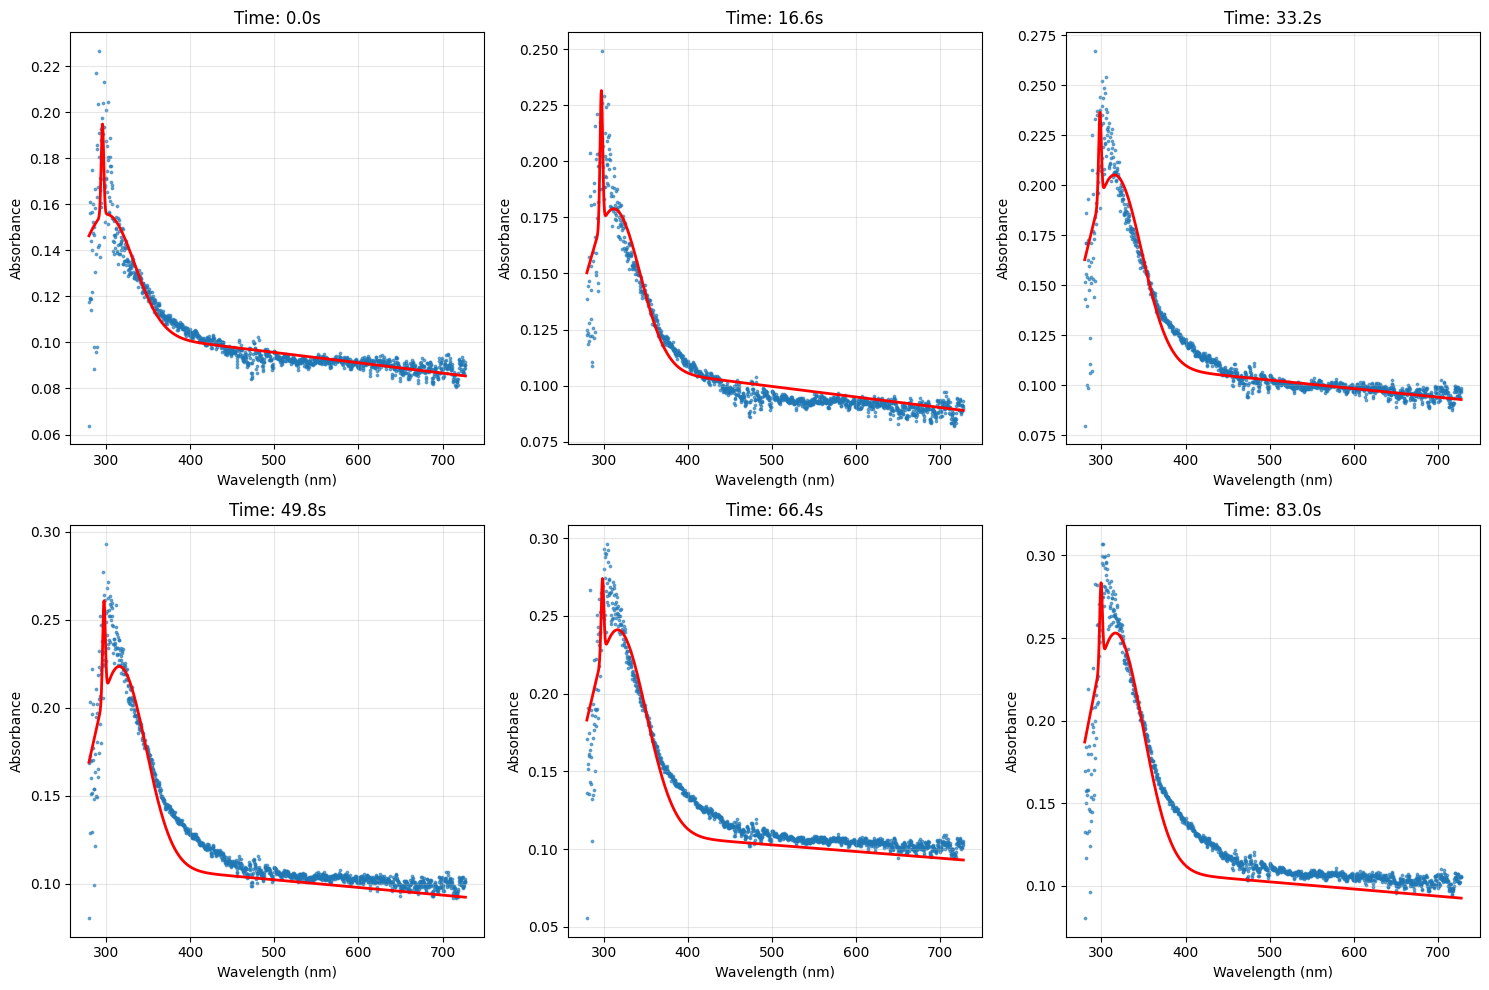

In [9]:
# Plot every 5th spectrum
n_plots = min(6, len(fit_results))
step = max(1, len(fit_results) // n_plots)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, i in enumerate(range(0, len(fit_results), step)[:n_plots]):
    time_point = data.columns[i]
    out = fit_results[i]
    x = data.index.values.astype(float)
    y = data[time_point].values
    
    axes[idx].scatter(x, y, s=3, alpha=0.6)
    axes[idx].plot(x, out.best_fit, 'r-', linewidth=2)
    axes[idx].set_title(f'Time: {time_point}')
    axes[idx].set_xlabel('Wavelength (nm)')
    axes[idx].set_ylabel('Absorbance')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Extract Peak Parameters Over Time

Extract and plot how peak parameters change over time:

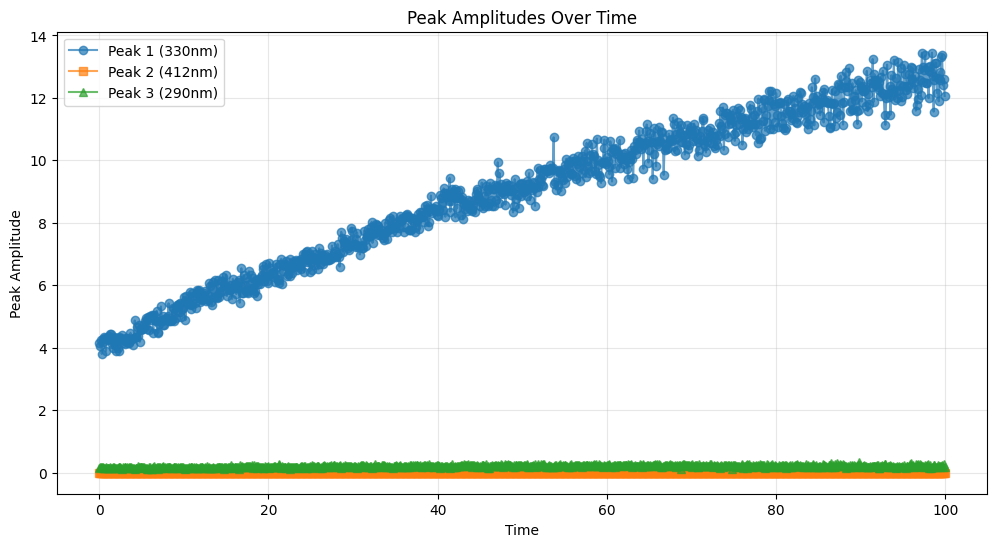

In [10]:
# Extract peak amplitudes over time
times = data.columns.to_list()
peak1_amps = [fit.params['peak1_amplitude'].value for fit in fit_results]
peak2_amps = [fit.params['peak2_amplitude'].value for fit in fit_results]
peak3_amps = [fit.params['peak3_amplitude'].value for fit in fit_results]

# Try to extract numeric time values
try:
    times_numeric = [float(t.replace('s', '')) if isinstance(t, str) else float(t) for t in times]
except (ValueError, TypeError, AttributeError):
    times_numeric = list(range(len(times)))

plt.figure(figsize=(12, 6))
plt.plot(times_numeric, peak1_amps, 'o-', label='Peak 1 (330nm)', alpha=0.7)
plt.plot(times_numeric, peak2_amps, 's-', label='Peak 2 (412nm)', alpha=0.7)
plt.plot(times_numeric, peak3_amps, '^-', label='Peak 3 (290nm)', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Peak Amplitude')
plt.title('Peak Amplitudes Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()